In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import glob
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

=== Inlier Distribution at R@1 (Tokyo-XS — MegaLoc + LoFTR) ===
Total evaluated queries: 315
Correct (<=25m): N=301 | Median=103.0 | Mean=133.6 | [Min=7, Max=590]
Incorrect (>25m): N=14 | Median=11.5 | Mean=14.9 | [Min=8, Max=33]



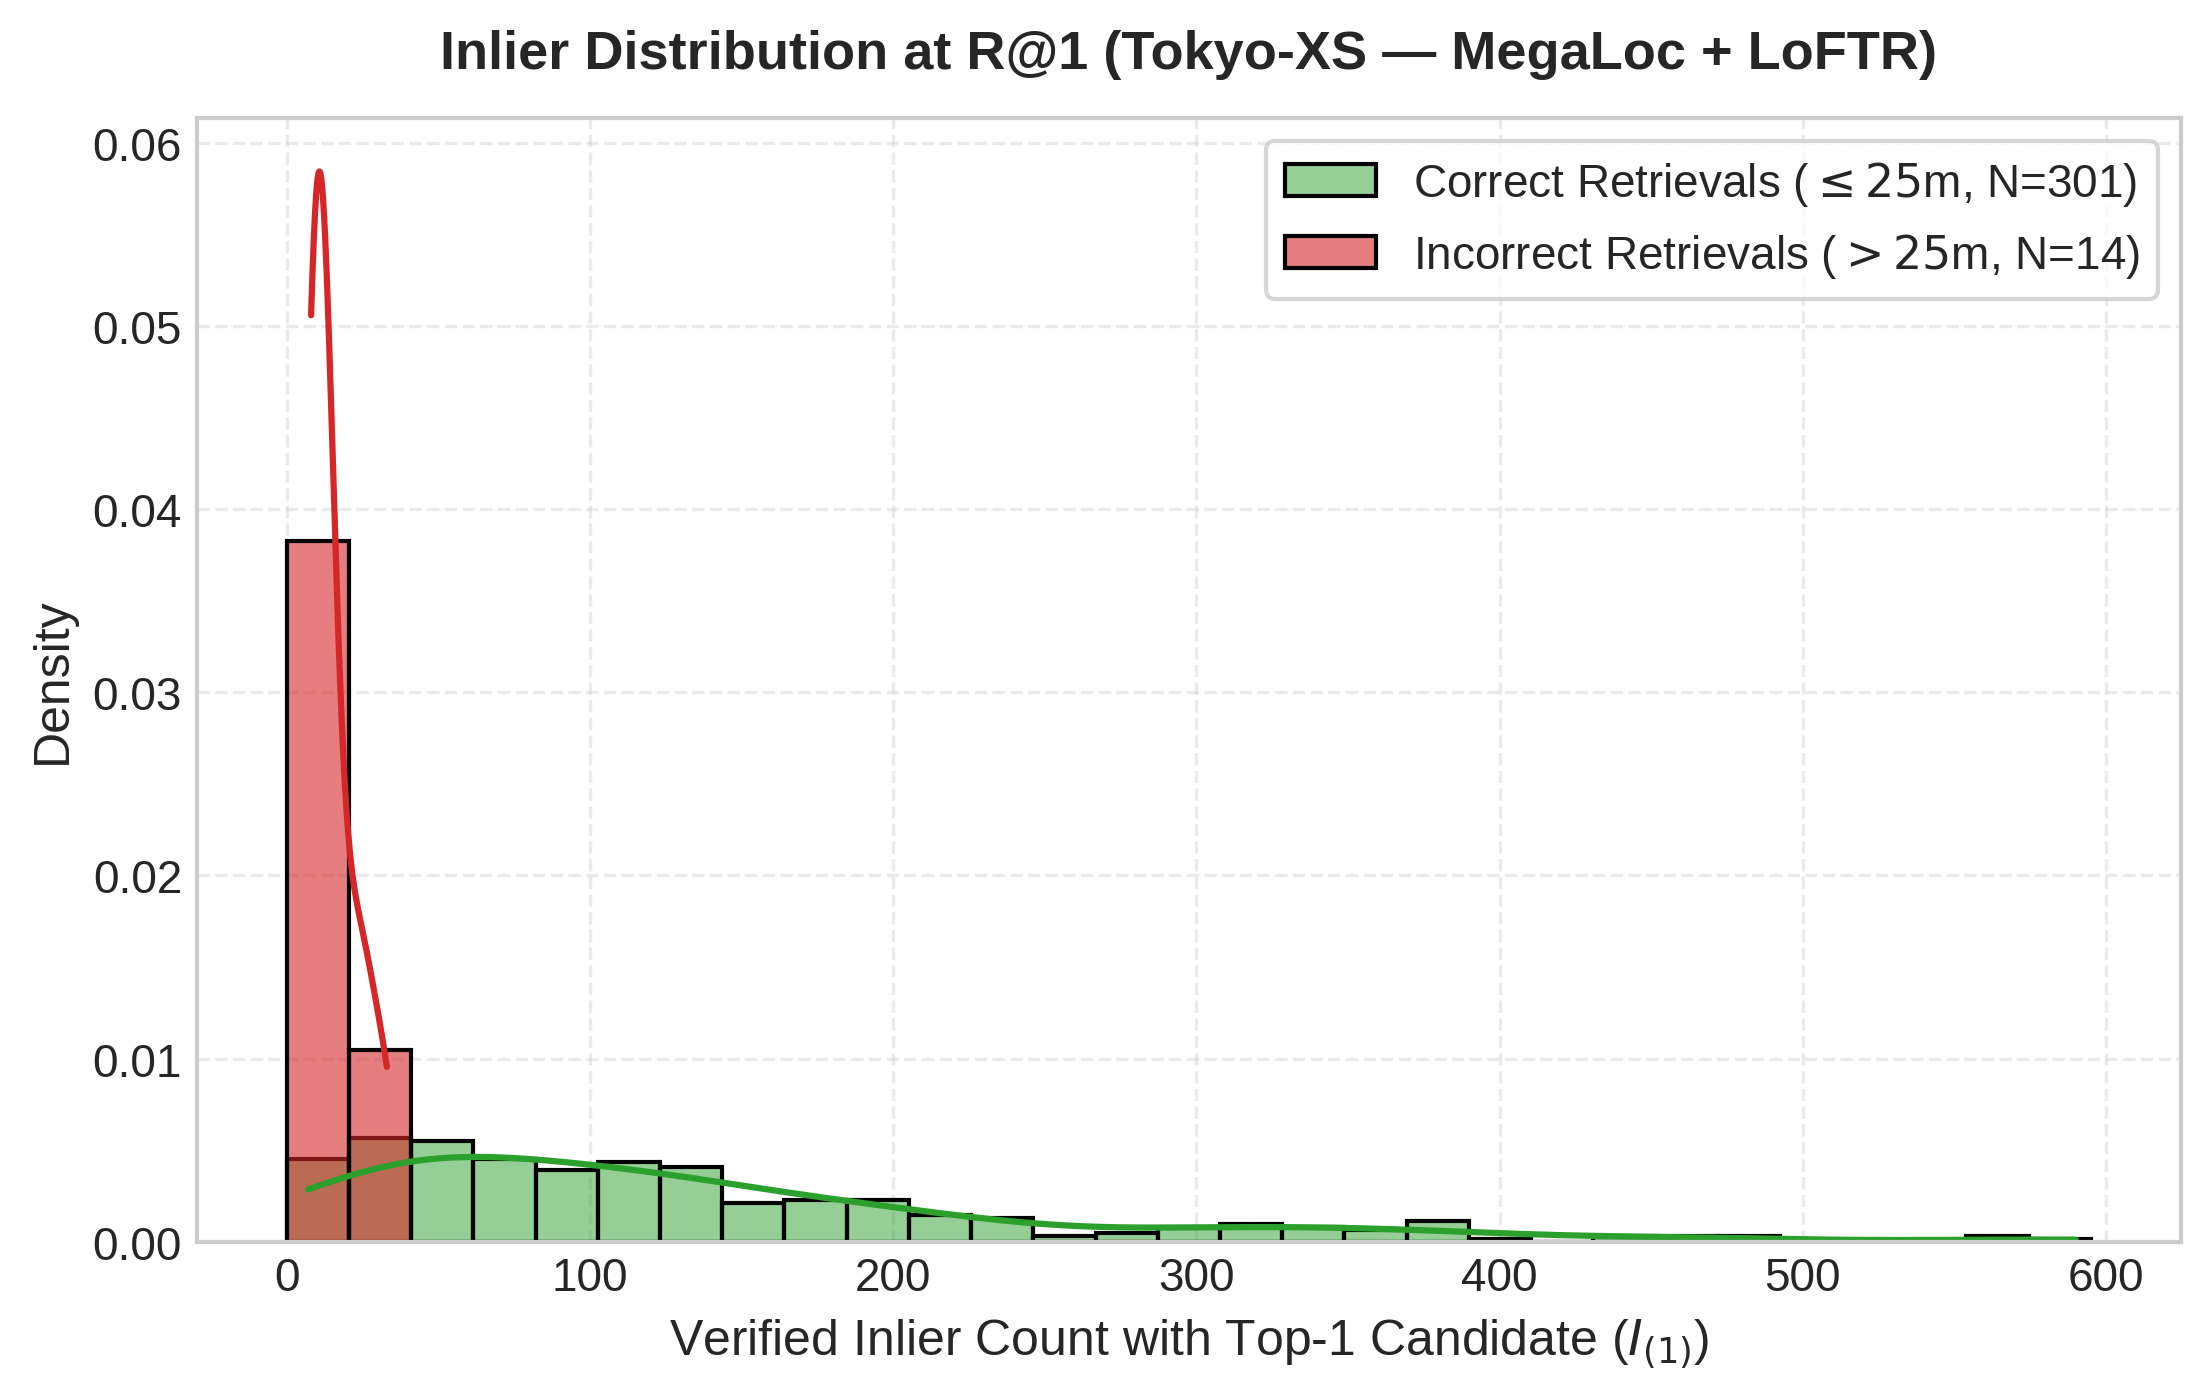

=== Inlier Distribution at R@1 (SF-XS — MegaLoc + SuperGlue) ===
Total evaluated queries: 1000
Correct (<=25m): N=868 | Median=21.0 | Mean=23.4 | [Min=4, Max=102]
Incorrect (>25m): N=132 | Median=6.0 | Mean=7.4 | [Min=2, Max=51]



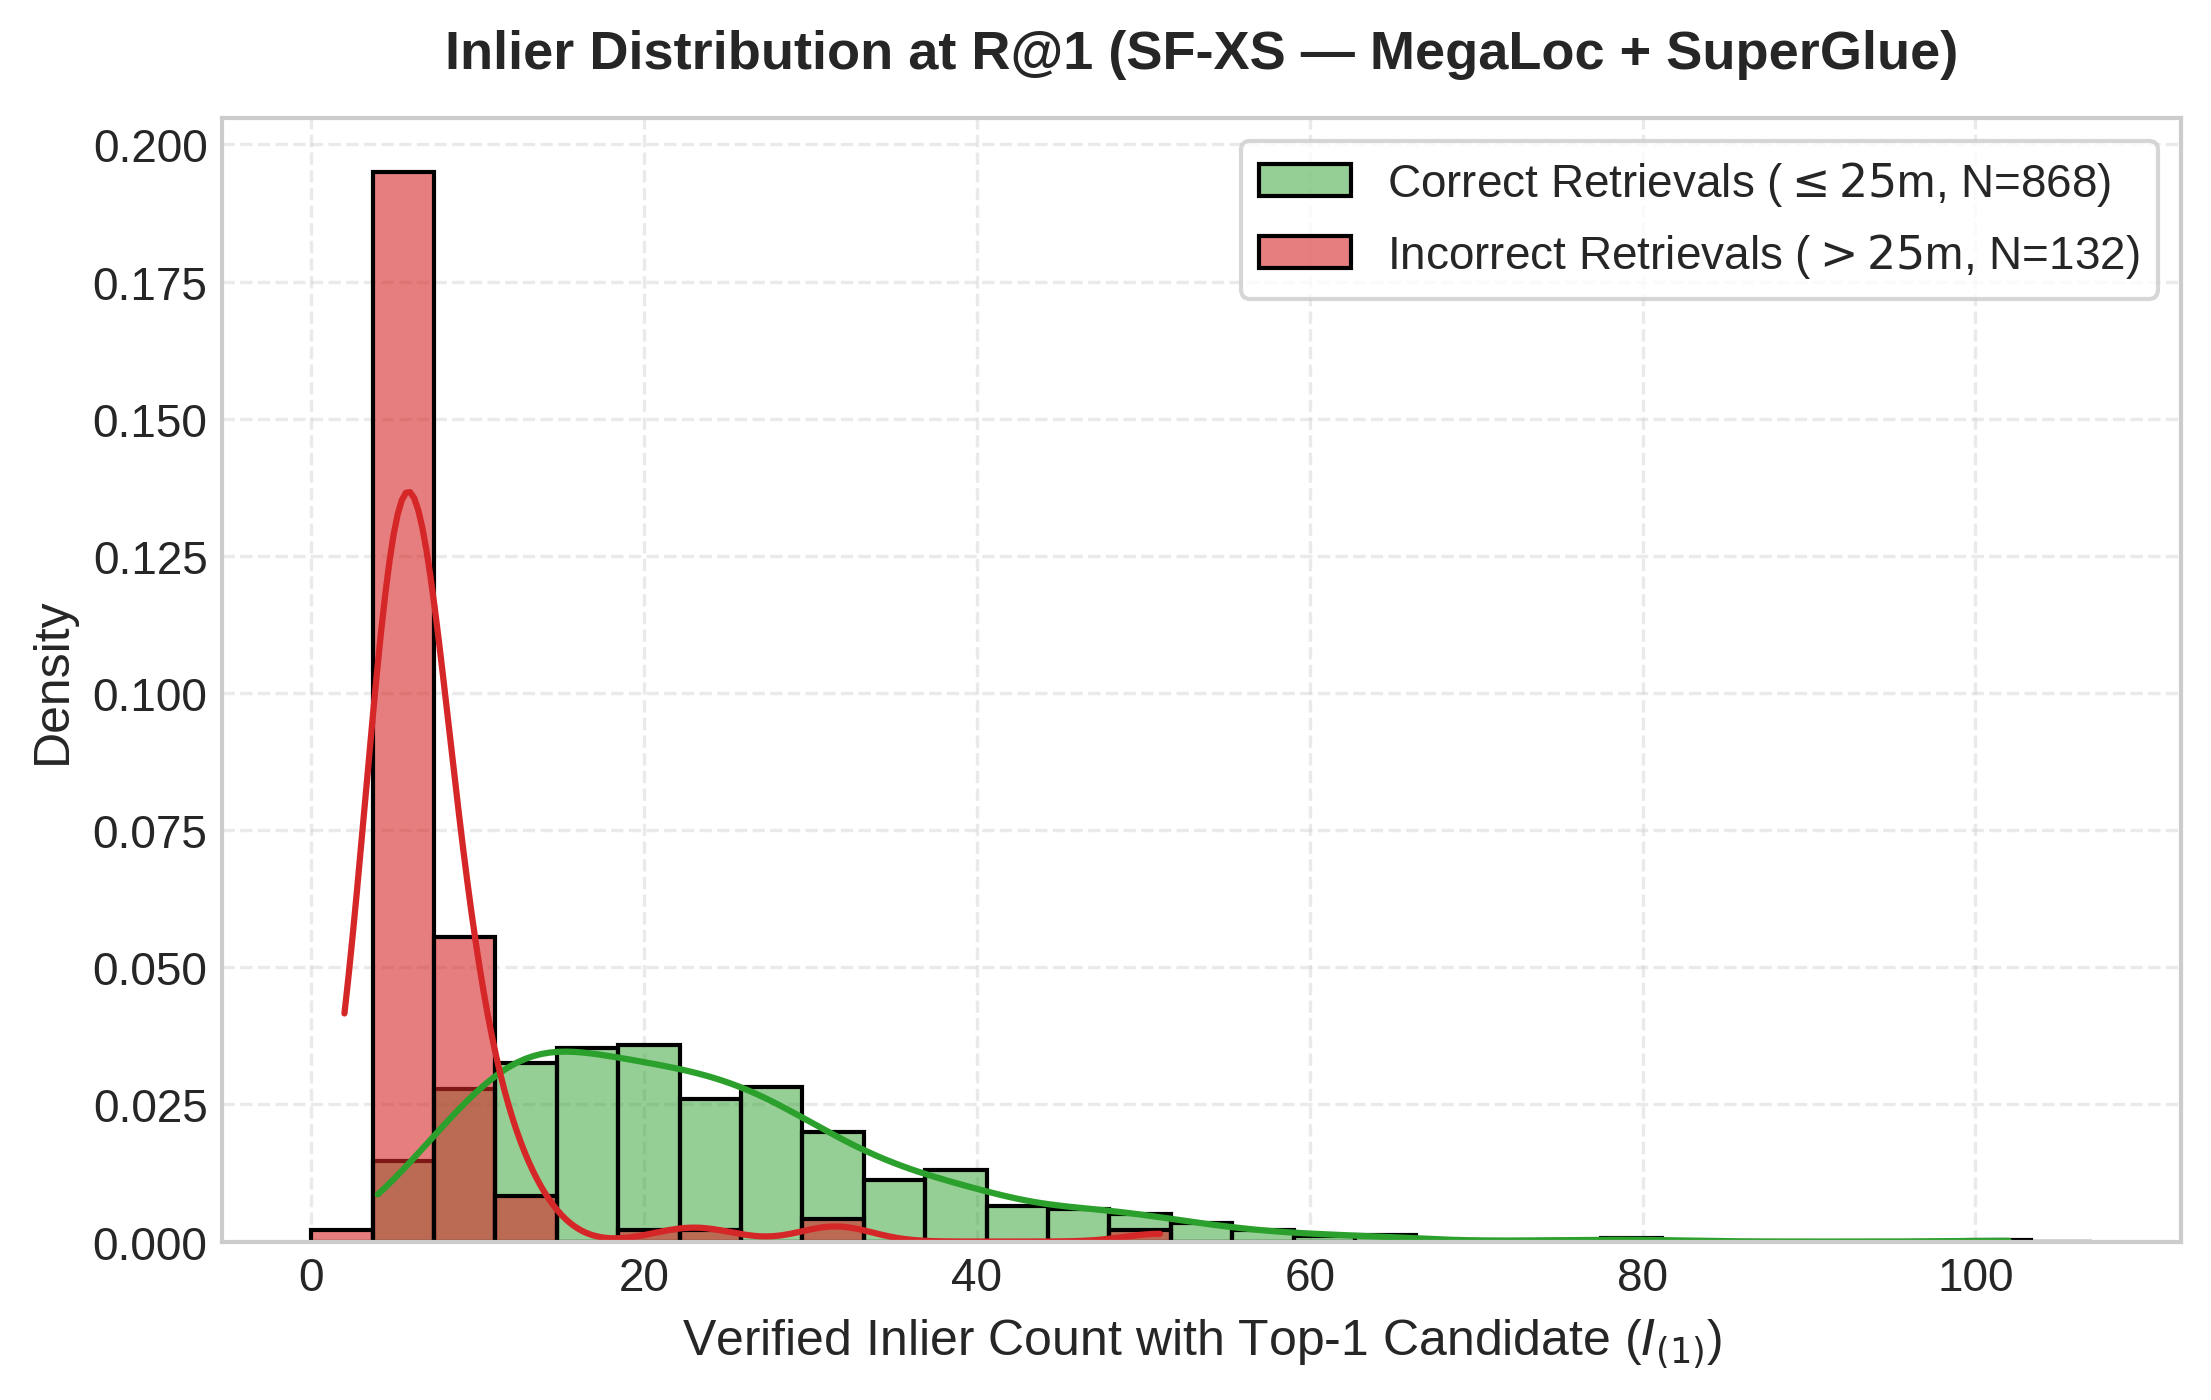

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

def extract_utm_coords(filepath):
    """Extracts (easting, northing) UTM coordinates from standard VPR filename."""
    filename = Path(filepath).name
    parts = filename.split('@')
    # Standard format: @<easting>@<northing>@...
    try:
        easting = float(parts[1])
        northing = float(parts[2])
        return np.array([easting, northing])
    except (IndexError, ValueError):
        return None

def analyze_inlier_distribution(preds_dir, inliers_dir, title, filename, threshold=25.0):
    txt_files = sorted(glob.glob(os.path.join(preds_dir, "*.txt")), key=lambda x: int(Path(x).stem))

    correct_inliers = []
    incorrect_inliers = []

    for txt_file in txt_files:
        with open(txt_file, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]

        if len(lines) < 4:
            continue

        # Line 1: Query path
        query_path = lines[1]
        # Line 3: "Predictions paths:", Line 4: Prediction 0 path
        pred0_path = lines[3] if not lines[2].startswith("Predictions") else lines[3]
        if "Predictions paths:" in lines:
            pred_idx = lines.index("Predictions paths:") + 1
            if pred_idx < len(lines):
                pred0_path = lines[pred_idx]
            else:
                continue

        q_coords = extract_utm_coords(query_path)
        p0_coords = extract_utm_coords(pred0_path)

        if q_coords is None or p0_coords is None:
            continue

        # Ground truth UTM distance in meters
        dist_top1 = np.linalg.norm(q_coords - p0_coords)

        # Inlier count for prediction 0
        torch_file = os.path.join(inliers_dir, Path(txt_file).name.replace('.txt', '.torch'))
        if not os.path.exists(torch_file):
            continue

        query_results = torch.load(torch_file, map_location="cpu", weights_only=False)
        if len(query_results) == 0:
            continue

        res0 = query_results[0]
        num_inliers = res0['num_inliers'] if isinstance(res0, dict) else int(res0)

        if dist_top1 <= threshold:
            correct_inliers.append(num_inliers)
        else:
            incorrect_inliers.append(num_inliers)

    correct_inliers = np.array(correct_inliers)
    incorrect_inliers = np.array(incorrect_inliers)

    print(f"=== {title} ===")
    print(f"Total evaluated queries: {len(correct_inliers) + len(incorrect_inliers)}")
    if len(correct_inliers) > 0:
        print(f"Correct (<=25m): N={len(correct_inliers)} | Median={np.median(correct_inliers):.1f} | Mean={np.mean(correct_inliers):.1f} | [Min={correct_inliers.min()}, Max={correct_inliers.max()}]")
    if len(incorrect_inliers) > 0:
        print(f"Incorrect (>25m): N={len(incorrect_inliers)} | Median={np.median(incorrect_inliers):.1f} | Mean={np.mean(incorrect_inliers):.1f} | [Min={incorrect_inliers.min()}, Max={incorrect_inliers.max()}]")
    print()

    plt.figure(figsize=(7.5, 4.8), dpi=300)

    max_val = max(correct_inliers.max() if len(correct_inliers) > 0 else 0,
                  incorrect_inliers.max() if len(incorrect_inliers) > 0 else 0)
    bins = np.linspace(0, max_val + 5, 30)

    if len(correct_inliers) > 0:
        sns.histplot(
            correct_inliers,
            bins=bins,
            color="#2ca02c",
            label=rf"Correct Retrievals ($\leq 25$m, N={len(correct_inliers)})",
            kde=True,
            stat="density",
            alpha=0.5,
            edgecolor="black"
        )

    if len(incorrect_inliers) > 0:
        sns.histplot(
            incorrect_inliers,
            bins=bins,
            color="#d62728",
            label=rf"Incorrect Retrievals ($> 25$m, N={len(incorrect_inliers)})",
            kde=True,
            stat="density",
            alpha=0.6,
            edgecolor="black"
        )

    plt.title(title, fontweight="bold", pad=12)
    plt.xlabel("Verified Inlier Count with Top-1 Candidate ($I_{(1)}$)")
    plt.ylabel("Density")
    plt.legend(frameon=True, loc="upper right")
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

# ----------------------------------------------------
# 1. Tokyo-XS (MegaLoc + LoFTR)
# ----------------------------------------------------
analyze_inlier_distribution(
    preds_dir="/content/drive/MyDrive/VPR_megaloc_logs/2026-08-22_16-47-53/preds",
    inliers_dir="/content/drive/MyDrive/VPR_megaloc_logs/2026-08-22_16-47-53/preds_loftr",
    title="Inlier Distribution at R@1 (Tokyo-XS — MegaLoc + LoFTR)",
    filename="fig_inliers_tokyo_loftr.pdf"
)

# ----------------------------------------------------
# 2. SF-XS (MegaLoc + SuperGlue)
# ----------------------------------------------------
analyze_inlier_distribution(
    preds_dir="/content/drive/MyDrive/VPR_megaloc_logs/2026-08-22_15-54-43/preds",
    inliers_dir="/content/drive/MyDrive/VPR_megaloc_logs/2026-08-22_15-54-43/preds_superglue",
    title="Inlier Distribution at R@1 (SF-XS — MegaLoc + SuperGlue)",
    filename="fig_inliers_sf_superglue.pdf"
)

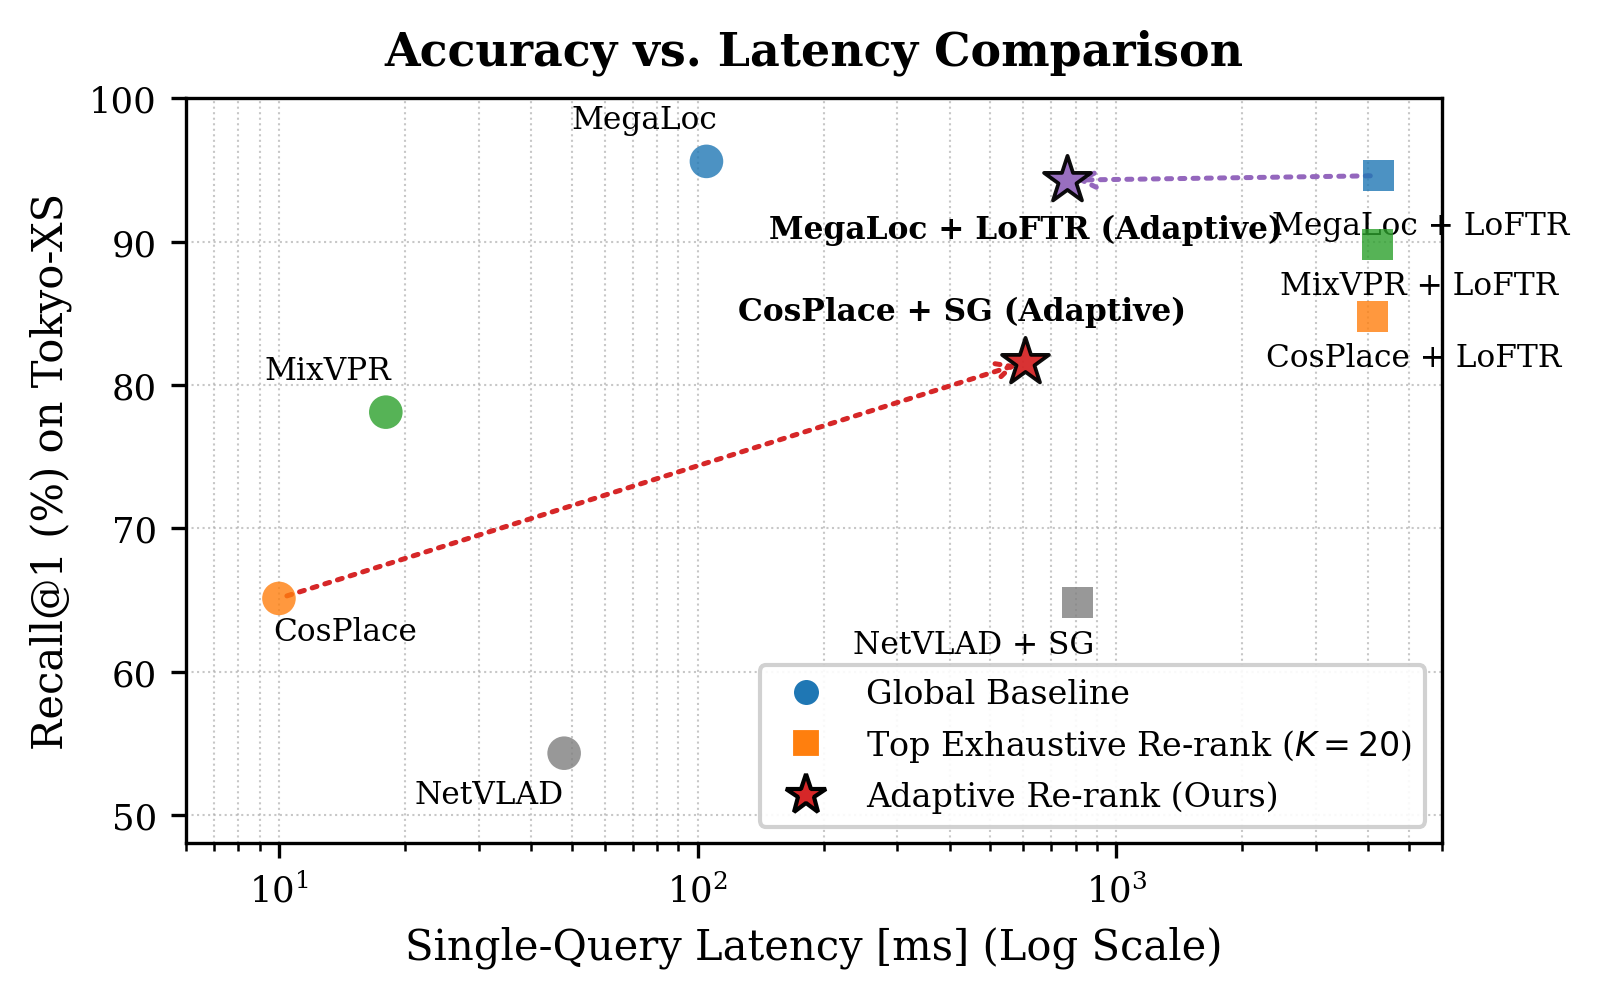

Generated clean: fig_frontier.pdf


In [4]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 8,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
})

fig, ax = plt.subplots(figsize=(5.4, 3.4), dpi=300)

points = [
    # 1. Standalone Global Baselines (Tokyo-XS)
    (48, 54.3, 'NetVLAD', '#7f7f7f', 'o', (-18, -12)),
    (10, 65.1, 'CosPlace', '#ff7f0e', 'o', (16, -10)),
    (18, 78.1, 'MixVPR', '#2ca02c', 'o', (-14, 8)),
    (105, 95.6, 'MegaLoc', '#1f77b4', 'o', (-15, 8)),

    # 2. Top-performing exhaustive re-rankers (Tokyo-XS, K=20)
    (810, 64.8, 'NetVLAD + SG', '#7f7f7f', 's', (-25, -12)),
    (4092, 84.8, 'CosPlace + LoFTR', '#ff7f0e', 's', (10, -12)),
    (4218, 89.8, 'MixVPR + LoFTR', '#2ca02c', 's', (10, -12)),
    (4235, 94.6, 'MegaLoc + LoFTR', '#1f77b4', 's', (10, -14)),

    # 3. Adaptive re-ranking (Tokyo-XS, tau_p = 0.2)
    # Expected latency:
    # CosPlace: 10 + (1534/20) * [1 + 0.3968*19] ~= 605 ms
    (605, 81.59, 'CosPlace + SG (Adaptive)', '#d62728', '*', (-15, 10)),

    # MegaLoc: 105 + (4235/20) * [1 + 0.1111*19] ~= 764 ms
    (764, 94.29, 'MegaLoc + LoFTR (Adaptive)', '#9467bd', '*', (-10, -14)),
]

for lat, rec, name, col, marker, offset in points:
  size = 140 if marker == '*' else (65 if marker == 'o' else 55)
  alpha = 0.95 if marker == '*' else 0.8
  edge = 'black' if marker == '*' else 'none'
  ax.scatter(
      lat,
      rec,
      color=col,
      marker=marker,
      s=size,
      alpha=alpha,
      edgecolors=edge,
      linewidth=0.9,
      zorder=4,
  )
  ax.annotate(
      name,
      (lat, rec),
      textcoords='offset points',
      xytext=offset,
      ha='center',
      fontsize=7.5,
      fontweight='bold' if marker == '*' else 'normal',
  )

# Shift vectors
ax.annotate(
    '',
    xy=(605, 81.59),
    xytext=(10, 65.1),
    arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.2, ls=':'),
)
ax.annotate(
    '',
    xy=(764, 94.29),
    xytext=(4235, 94.6),
    arrowprops=dict(arrowstyle='->', color='#9467bd', lw=1.2, ls=':'),
)

# Formatting
ax.set_xscale('log')
ax.set_xlim(6, 6000)
ax.set_ylim(48, 100)
ax.set_xlabel('Single-Query Latency [ms] (Log Scale)')
ax.set_ylabel('Recall@1 (%) on Tokyo-XS')
ax.set_title('Accuracy vs. Latency Comparison', fontweight='bold', pad=8)
ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.7)

# Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Global Baseline',
        markerfacecolor='#1f77b4',
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker='s',
        color='w',
        label='Top Exhaustive Re-rank ($K=20$)',
        markerfacecolor='#ff7f0e',
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker='*',
        color='w',
        markeredgecolor='black',
        label='Adaptive Re-rank (Ours)',
        markerfacecolor='#d62728',
        markersize=10,
    ),
]
ax.legend(
    handles=legend_elements, loc='lower right', frameon=True, framealpha=0.9
)

plt.tight_layout()
plt.savefig('fig_frontier.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Generated clean: fig_frontier.pdf')